
Total inmigrantes internacionales en Los Ríos: 7,508


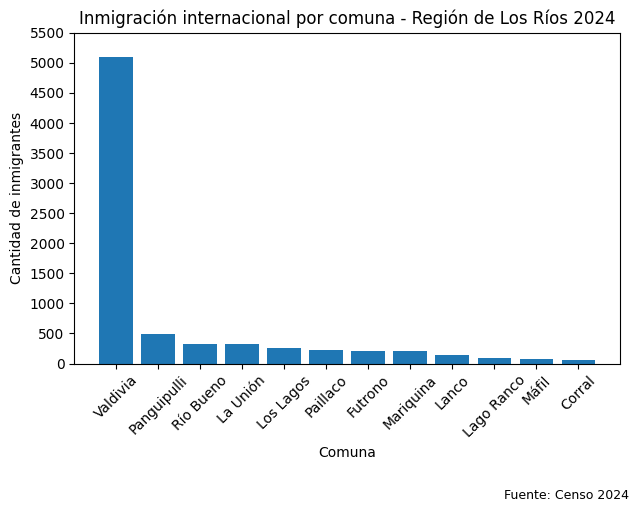

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Se lee el archivo desde la fila 4 porque ahi estan las columnas (empieza la tabla).
df = pd.read_excel(
    "D4_Inmigracion-Internacional.xlsx",
    sheet_name="4",
    skiprows=3
)
#Se quitan espacios indeseados que puedan entorpecer el análisis.
df.columns = df.columns.str.strip()

colMigrantes = df.columns[7] #Columna H en el excel.

#se agarran únicamente las filas de la región de los ríos.
dfLosRios = df[df["Región"] == "Los Ríos"].copy()

#Se quitan los datos que estan en las filas que contienen el total (para evitar que de el doble).
dfLosRios = dfLosRios[
    ~dfLosRios["País o continente de nacimiento"]
    .str.contains("Total nacidos fuera del país", na=False)
]

#Se agrupan los datos por columna, se suman todas las columnas con países extranjeros.
migrantesComuna = (
    dfLosRios
    .groupby("Comuna")[colMigrantes]
    .sum()
    .reset_index()
)

#Se ordena de mayor a menor.
migrantesComuna = migrantesComuna.sort_values(
    by=colMigrantes,
    ascending=False
)

#Se imprimen los migrantes (para comprobar los datos del Censo: 7508).
total = migrantesComuna[colMigrantes].sum()
print(f"\nTotal inmigrantes internacionales en Los Ríos: {int(total):,}")

#Se grafica.
plt.figure()
plt.bar(
    migrantesComuna["Comuna"], #Leyenda.
    migrantesComuna[colMigrantes] #Valores.
)

plt.xticks(rotation=45) #Estetica rotación para la leyenda vertical.
plt.title("Inmigración internacional por comuna - Región de Los Ríos 2024")
plt.xlabel("Comuna")
plt.ylabel("Cantidad de inmigrantes")
maxValY = migrantesComuna[colMigrantes].max()
plt.yticks(np.arange(0, maxValY + 500, 500))
#Ponerle la fuente, para respaldar el gráfico.
plt.figtext(0.99, -0.05, "Fuente: Censo 2024", 
            horizontalalignment='right', fontsize=9)

plt.tight_layout()
plt.show()